Question 1 (35 pt)

A sample of 30 respondents was interviewed using mall intercept interviewing. The respondents were asked to indicate their degree of agreement with the following statements using a seven-point scale (1 = strongly disagree, 7 = strongly agree).

•	V1 = It is important to buy a toothpaste that prevents cavities

•	V2 = I like a toothpaste that gives a shiny teeth

•	V3 = A toothpaste should strengthen your gums teeth

•	V4 = I prefer a toothpaste that freshens breath

•	V5 = Prevention of tooth decay is not an important benefit offered by a toothpaste

•	V6 = The most important consideration in buying a toothpaste is attractive teeth

By using the variables,

(1) How many factors is extracted from data for principal component analysis?

(2) What is the total percentage of variance explained by these principal components?

(3)Which variables are included in the same factors ? How can you name these factors?

You can find the data at

https://raw.githubusercontent.com/ogut77/DataScience/main/data/Toothpaste.csv

In [1]:
!pip install factor_analyzer
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer

# Load dataset
url = "https://raw.githubusercontent.com/ogut77/DataScience/main/data/Toothpaste.csv"
data = pd.read_csv(url)

# Select variables
X = data[['V1','V2','V3','V4','V5','V6']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
pca.fit(X_scaled)

# Eigenvalues
eigenvalues = pca.explained_variance_
print("Eigenvalues:\n", eigenvalues)

# Variance explained
variance = pca.explained_variance_ratio_
cumulative = np.cumsum(variance)

print("\nVariance Explained:\n", variance)
print("\nCumulative Variance:\n", cumulative)

# Factor Analysis with Varimax rotation
fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(X_scaled)

loadings = pd.DataFrame(fa.loadings_,
                        index=['V1','V2','V3','V4','V5','V6'],
                        columns=['Factor1','Factor2'])

print("\nRotated Factor Loadings:\n", loadings)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=debfbf66221096d8476e2b4e23d75db14846e6663953ef9290aea67f14338cfc
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer
Eigenvalues:
 [2.46705648 1.88039204 1.00213895 0.44264638 0.31892987 0.09573284]

Variance Explained:
 [0.39747021 0.30295205 0.16145572 0.07131525 0.05138315 0.01542362]

Cumulative Variance:
 [0.39747021 0.70042226 0.86187798 0.93319323 0.98457638 1.        ]

Rotated Factor Loadings:
      Factor1   Factor2
V1  0.031350  0.873523
V2  0.751605 -0.102783
V3 -0.071745  0.992173
V4  0.753931 -0.170942
V5  0.059463 -0.188382
V6  0.848066  0.025653


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [2]:
#Q2  is below
# Data description is provided below
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Leads.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [3]:
 #There are missing values in the Lead data .
# Replace missing variables with the mean  if variable is numeric or mode if variable is categorical.
for col in df.columns:
    if ((df[col].dtype == 'float64') or (df[col].dtype == 'float64')) :
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


In [4]:
#Check that there are no missing data
df.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split



df = df.drop(columns=['Prospect ID','Lead Number'])
y = df['Converted']
X = df.drop(columns=['Converted'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

In [6]:
def eval(yact,ypred):
 from sklearn import metrics
 print("Accuracy:",metrics.accuracy_score(yact, ypred))
 print("Precision:",metrics.precision_score(yact, ypred))
 print("Recall:",metrics.recall_score(yact, ypred))

 cnf_matrix = metrics.confusion_matrix(yact, ypred)
 import numpy as np
 import matplotlib.pyplot as plt
 import seaborn as sns
 %matplotlib inline
 class_names=[0,1] # name  of classes
 fig, ax = plt.subplots()
 tick_marks = np.arange(len(class_names))
 plt.xticks(tick_marks, class_names)
 plt.yticks(tick_marks, class_names)
 # create heatmap
 sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
 ax.xaxis.set_label_position("top")
 plt.tight_layout()
 plt.title('Confusion matrix', y=1.1)
 plt.ylabel('Actual label')
 plt.xlabel('Predicted label')


In [7]:
#Q2(30 pt)-Using Autogluon  AutoML tools,make prediction on test data and evaluate performance of prediction using eval function defined above.
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [19]:
for col in df.columns:
    print(f"'{col}'")

'Lead Origin'
'Lead Source'
'Do Not Email'
'Do Not Call'
'Converted'
'TotalVisits'
'Total Time Spent on Website'
'Page Views Per Visit'
'Last Activity'
'Country'
'Specialization'
'How did you hear about X Education'
'What is your current occupation'
'What matters most to you in choosing a course'
'Search'
'Magazine'
'Newspaper Article'
'X Education Forums'
'Newspaper'
'Digital Advertisement'
'Through Recommendations'
'Receive More Updates About Our Courses'
'Tags'
'Lead Quality'
'Update me on Supply Chain Content'
'Get updates on DM Content'
'Lead Profile'
'City'
'Asymmetrique Activity Index'
'Asymmetrique Profile Index'
'Asymmetrique Activity Score'
'Asymmetrique Profile Score'
'I agree to pay the amount through cheque'
'A free copy of Mastering The Interview'
'Last Notable Activity'


In [20]:
df.columns = df.columns.str.strip()

In [21]:
df = df.drop(columns=['Prospect ID','Lead Number'], errors='ignore')

In [22]:
'ProspectID'
'Lead_Number'

'Lead_Number'

In [24]:
df = df.copy()

In [25]:
df.columns = df.columns.str.strip()

cols_to_drop = [col for col in ['Prospect ID','Lead Number'] if col in df.columns]
df = df.drop(columns=cols_to_drop)

In [26]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df, test_size=0.3, random_state=42)

label = 'Converted'

In [29]:
print(df.columns)

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization',
       'How did you hear about X Education', 'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')


In [32]:
df = df.drop(columns=['Prospect ID','Lead Number'], errors='ignore')

In [35]:
df.columns = df.columns.str.strip()

cols_to_drop = ['Prospect ID','Lead Number']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [37]:
#Q3(35 pt)-Using data below, find how many clusters are there based on elbow method for k-means
#and hierarchical clustering
import pandas as pd
import numpy as np
cl = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/refs/heads/main/cluster.csv')
cl

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


      f1    f2    f3    f4   f5    f6    f7    f8    f9   f10   f11   f12  \
0  14.23  1.71  2.43  15.6  127  2.80  3.06  0.28  2.29  5.64  1.04  3.92   
1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28  4.38  1.05  3.40   
2  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81  5.68  1.03  3.17   
3  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18  7.80  0.86  3.45   
4  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82  4.32  1.04  2.93   

    f13  
0  1065  
1  1050  
2  1185  
3  1480  
4   735  


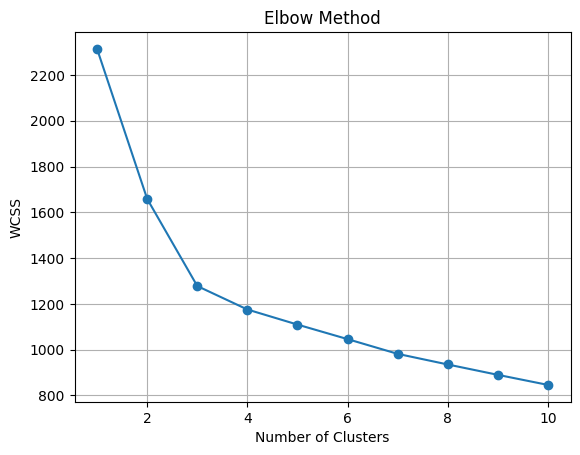

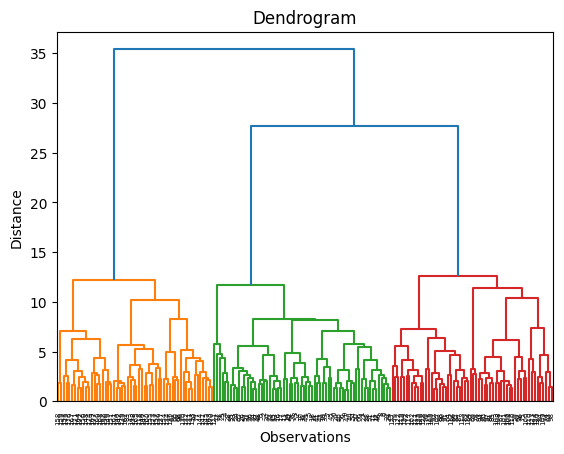

      f1    f2    f3    f4   f5    f6    f7    f8    f9   f10   f11   f12  \
0  14.23  1.71  2.43  15.6  127  2.80  3.06  0.28  2.29  5.64  1.04  3.92   
1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28  4.38  1.05  3.40   
2  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81  5.68  1.03  3.17   
3  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18  7.80  0.86  3.45   
4  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82  4.32  1.04  2.93   

    f13  Cluster  
0  1065        2  
1  1050        2  
2  1185        2  
3  1480        2  
4   735        2  


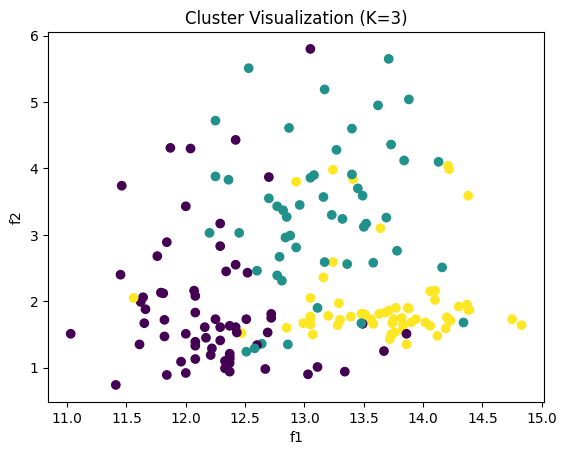

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch

# -----------------------------
# Step 1: Load Data
# -----------------------------
cl = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/refs/heads/main/cluster.csv')
print(cl.head())

# -----------------------------
# Step 2: Standardize Data
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cl)

# -----------------------------
# Step 3: Elbow Method (K-means)
# -----------------------------
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid()
plt.show()

# -----------------------------
# Step 4: Hierarchical Clustering (Dendrogram)
# -----------------------------
plt.figure()
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.show()

# -----------------------------
# Step 5: Apply K-means (K=3)
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
cl['Cluster'] = clusters

print(cl.head())

# -----------------------------
# Step 6: Cluster Visualization (Scatter Plot)
# -----------------------------
plt.figure()

# Use first two variables for visualization
plt.scatter(cl.iloc[:, 0], cl.iloc[:, 1], c=cl['Cluster'])

plt.xlabel(cl.columns[0])
plt.ylabel(cl.columns[1])
plt.title('Cluster Visualization (K=3)')

plt.show()